# Multi-Label Image Classification - Ablation Study A-F
## EfficientNet-B0 + CBAM + ASL trên MS COCO 2017 (Kaggle T4)

Notebook này huấn luyện **6 thực nghiệm (Exp A–F)** theo thiết kế ablation study,
sau đó đánh giá và phân tích kết quả đầy đủ.

| Exp | Backbone | CBAM | Loss | Mục đích |
|-----|----------|------|------|----------|
| A | ResNet50 | Yes | BCE | Baseline |
| B | ResNet50 | No | ASL | Đóng góp ASL |
| C | EfficientNet-B0 | Yes | ASL | Kiến trúc đề xuất |
| D | ResNet50 | No | Focal | So sánh loss |
| E | ResNet50 | Yes | ASL | CBAM trên backbone lớn |
| F | EfficientNet-B0 | No | ASL | Tách đóng góp CBAM |

**Luồng thực thi:**
1. Cài thư viện & kiểm tra GPU
2. Clone repo & verify fixes
3. Chuẩn bị dữ liệu COCO 2017 subset
4. Huấn luyện Exp A -> B -> C -> D -> E -> F
5. Vẽ đường cong & tóm tắt ablation


## Cell 1. Cài đặt thư viện và kiểm tra GPU

Cài các thư viện cần thiết và in thông tin GPU. Chạy một lần duy nhất
khi khởi động session Kaggle.


In [1]:
# Cài đặ thư viên
!pip install timm pycocotools torchmetrics scikit-learn matplotlib seaborn pyyaml tqdm -q

import torch

assert torch.cuda.is_available(), "GPU không khả dụng! Bật GPU: Settings -> Accelerator -> GPU T4."

print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")


GPU   : Tesla T4
VRAM  : 15.6 GB
PyTorch: 2.10.0+cu128


## Cell 2. Clone repository từ GitHub

Clone repo `ECAAL` chứa toàn bộ source code (`train.py`, `evaluate.py`,
`models.py`, `dataset.py`, `losses.py`, `cbam.py`) và config YAML cho 6 experiments.

> **Fixes quan trọng đã có trong repo:**
> - `evaluate.py`: bỏ `autocast` khi inference -> fp32 sigmoid -> mAP chính xác
> - `exp_C config`: bỏ `eps: 1e-5` -> gradient signal đầy đủ


In [2]:
import os
from pathlib import Path

REPO_URL = "https://github.com/Thinh59/ECAAL.git"
REPO_DIR = Path("/kaggle/working/ECAAL")

if REPO_DIR.exists():
    print("Repo đã tồn tại - pulling latest...")
    ret = os.system(f"git -C {REPO_DIR} pull")
else:
    print(f"Cloning {REPO_URL} ...")
    ret = os.system(f"git clone {REPO_URL} {REPO_DIR}")

if ret != 0:
    raise RuntimeError("git clone/pull thất bại! Kiểm tra kết nối internet (Settings -> Internet -> On).")

# Kiểm tra các file bắt buộc
REQUIRED = [
    "src/train.py", "src/losses.py", "src/models.py",
    "src/dataset.py", "src/evaluate.py", "src/cbam.py", "src/utils.py",
    "configs/exp_A_resnet_bce.yaml",
    "configs/exp_B_resnet_asl.yaml",
    "configs/exp_C_efficientnet_cbam_asl.yaml",
    "configs/exp_D_resnet_focal.yaml",
    "configs/exp_E_resnet_cbam_asl.yaml",
    "configs/exp_F_efficientnet_asl.yaml",
]

missing = [r for r in REQUIRED if not (REPO_DIR / r).exists()]
if missing:
    raise FileNotFoundError(f"File bị thiếu: {missing}")

print(f"\nRepository OK {len(REQUIRED)} file kiểm tra xong.")


Cloning https://github.com/Thinh59/ECAAL.git ...


Cloning into '/kaggle/working/ECAAL'...



Repository OK 13 file kiểm tra xong.


## Cell 3. Xác minh các bản vá (fixes)

Kiểm tra tự động rằng repo đã áp dụng đúng 3 fixes quan trọng trước khi train:

1. **ASL**: probability shifting đúng chiều (clip xs_pos, không phải xs_neg)
2. **evaluate_model**: không dùng `autocast` -> fp32 sigmoid -> mAP chính xác
3. **exp_C config**: không có `eps` thừa trong block `loss`


In [3]:
import sys
from pathlib import Path

REPO_DIR    = Path("/kaggle/working/ECAAL")
COCO_ROOT   = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
OUTPUTS_DIR = Path("/kaggle/working/outputs")
SUBSET_DIR  = Path("/kaggle/working/data/coco_subset")
DEVICE      = "cuda"
sys.path.insert(0, str(REPO_DIR / "src"))

import sys, inspect, yaml, torch

sys.path.insert(0, str(REPO_DIR / "src"))
from losses import AsymmetricLoss
from evaluate import evaluate_model

src_asl = inspect.getsource(AsymmetricLoss.forward)
fix1 = "xs_pos_shifted = (xs_pos - self.clip).clamp(min=0)" in src_asl
fix1_no_bug = "xs_neg_shifted = (xs_neg + self.clip)" not in src_asl

src_eval = inspect.getsource(evaluate_model)
fix2 = "autocast" not in src_eval

cfg_c = yaml.safe_load(open(REPO_DIR / "configs/exp_C_efficientnet_cbam_asl.yaml"))
fix3 = "eps" not in cfg_c.get("loss", {})

asl = AsymmetricLoss(gamma_pos=0, gamma_neg=4, clip=0.05)
logits  = torch.tensor([[10., -10., 5., -5.]] * 8)
targets = torch.randint(0, 2, (8, 4)).float()
loss    = asl(logits, targets)
fix4    = not torch.isnan(loss)
print(f"{'Ok' if fix4 else 'Bug'} Smoke test - ASL không NaN (loss={loss.item():.4f})")

if not all([fix1, fix1_no_bug, fix2, fix3, fix4]):
    raise RuntimeError("Bug: Một hoặc nhiều fix chưa được áp dụng - kiểm tra lại repo!")

print("\n Tất cả fixes đã xác minh, sẵn sàng train!")


Ok Smoke test - ASL không NaN (loss=12.0215)

 Tất cả fixes đã xác minh, sẵn sàng train!


## Cell 4. Khởi tạo thư mục và hằng số toàn cục

Định nghĩa các đường dẫn dùng chung cho toàn notebook.


In [4]:
from pathlib import Path
REPO_DIR = Path("/kaggle/working/ECAAL")

import os
from pathlib import Path

# Đường dẫn
COCO_ROOT   = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
OUTPUTS_DIR = Path("/kaggle/working/outputs")
SUBSET_DIR  = Path("/kaggle/working/data/coco_subset")
DEVICE      = "cuda"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
SUBSET_DIR.mkdir(parents=True, exist_ok=True)
os.chdir("/kaggle/working")

print(f"COCO root   : {COCO_ROOT}")
print(f"Outputs dir : {OUTPUTS_DIR}")
print(f"Subset dir  : {SUBSET_DIR}")
print(f"Working dir : {os.getcwd()}")


COCO root   : /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017
Outputs dir : /kaggle/working/outputs
Subset dir  : /kaggle/working/data/coco_subset
Working dir : /kaggle/working


## Cell 5. Kiểm tra dataset COCO 2017

> **Trước khi chạy:** Notebook -> **+ Add Data** -> tìm `coco-2017-dataset` (awsaf49) -> Add.
> Dataset sẽ mount tự động tại `/kaggle/input/coco-2017-dataset/`.


In [5]:
import os
COCO_ROOT = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"

checks = [
    ("Annotation train", f"{COCO_ROOT}/annotations/instances_train2017.json"),
    ("Annotation val",   f"{COCO_ROOT}/annotations/instances_val2017.json"),
    ("Images train2017", f"{COCO_ROOT}/train2017"),
    ("Images val2017",   f"{COCO_ROOT}/val2017"),
]

all_ok = True
for name, path in checks:
    ok = os.path.exists(path)
    print(f"  {'Ok' if ok else 'Bug'} {name:20s}  {path}")
    if not ok:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        "Dataset COCO 2017 chưa được add.\n"
        "-> Notebook -> + Add Data -> tìm 'coco-2017-dataset' (awsaf49) -> Add."
    )
print("\n Dataset COCO 2017 sẵn sàng.")


  Ok Annotation train      /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json
  Ok Annotation val        /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json
  Ok Images train2017      /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
  Ok Images val2017        /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017

 Dataset COCO 2017 sẵn sàng.


## Cell 6. Tạo COCO 2017 Subset (16 k train / 1 k val / 4 k test)

Chia stratified subset từ COCO 2017 để đảm bảo phân phối nhãn đồng đều.
Nếu subset đã tồn tại, bước này bị bỏ qua để tiết kiệm thời gian.

| Split | Số ảnh | Nguồn |
|-------|--------|-------|
| Train | 16 000 | train2017 |
| Val   |  1 000 | val2017 |
| Test  |  4 000 | val2017 (held-out, không dùng trong val) |


In [6]:
import sys
from pathlib import Path

REPO_DIR    = Path("/kaggle/working/ECAAL")
COCO_ROOT   = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
OUTPUTS_DIR = Path("/kaggle/working/outputs")
SUBSET_DIR  = Path("/kaggle/working/data/coco_subset")
DEVICE      = "cuda"
sys.path.insert(0, str(REPO_DIR / "src"))

train_f = SUBSET_DIR / "subset_train_ids.json"
val_f   = SUBSET_DIR / "subset_val_ids.json"
test_f  = SUBSET_DIR / "subset_test_ids.json"

if train_f.exists() and val_f.exists() and test_f.exists():
    import json
    print("Subset đã tồn tại, bỏ qua bước tạo.")
    print(f"   train : {len(json.load(open(train_f))):,} ảnh")
    print(f"   val   : {len(json.load(open(val_f))):,} ảnh")
    print(f"   test  : {len(json.load(open(test_f))):,} ảnh")
else:
    import sys
    sys.path.insert(0, str(REPO_DIR / "src"))
    from dataset import create_coco_subset
    create_coco_subset(
        coco_root=COCO_ROOT,
        output_dir=str(SUBSET_DIR),
        num_train=16000,
        num_val=1000,
        num_test=4000,
        seed=42,
    )
    print("Subset tạo xong!")


[Subset] COCO 2017 train: 16000 ids
[Subset] COCO 2017 val:  1000 ids
[Subset] COCO 2017 test: 3952 ids (from val2017, no overlap with val)
Subset tạo xong!


## Cell 7. Train Experiment A: ResNet50 + BCE (Baseline)

Baseline đơn giản nhất. ResNet50 pretrained + BCE loss tiêu chuẩn.\nKết quả này làm mức tham chiếu cho tất cả experiments còn lại.


In [7]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py \
    --config /kaggle/working/ECAAL/configs/exp_A_resnet_bce.yaml


[Exp] exp_A_resnet_bce | device=cuda
[DataLoader] augment='standard', img_size=224, batch=64
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
model.safetensors: 100%|█████████████████████| 102M/102M [00:01<00:00, 68.1MB/s]
[Model] resnet50 | CBAM=False | Dropout=0.3 | Params=23.67M | FeatChannels=2048
[Loss] BCE | params: {}

--- Epoch 1/20 ---
  [50/250] loss=0.6749
  [100/250] loss=0.6417
  [150/250] loss=0.5823
  [200/250] loss=0.5036
  [250/250] loss=0.4348
  train_loss=0.4348

--- Epoch 2/20 ---
  [50/250] loss=0.1346
  [100/250] loss=0.1290
  [150/250] loss=0.1235
  [200/250] loss=0.1183
  [250/250] loss=0.1138
[Epoch 2] mAP=0.4468 | macro_f1=0.4336 | micro_f1=0.5602 | train_loss=0.1138
[Ckpt] Saved → /kaggle/working/outputs/exp_A_resnet_bce/best.pth
 Best mAP: 0.4468

--- Epoch 3/20 ---
  [50/250] loss=0.0869
  [100/250] loss=0.0847
  [150/250] loss=0.0825
  [200/250] loss=0.0811
  [250/250] loss=0.0796
  train_loss=0.0796

--- Epoch 4/20 ---
  [50/250

## Cell 8. Train Experiment B: ResNet50 + ASL

Thay BCE bằng **Asymmetric Loss (ASL)**. Cùng backbone ResNet50.\nSo sánh B vs A → đóng góp thuần túy của ASL.


In [8]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py \
    --config /kaggle/working/ECAAL/configs/exp_B_resnet_asl.yaml


[Exp] exp_B_resnet_asl | device=cuda
[DataLoader] augment='standard', img_size=224, batch=64
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
[Model] resnet50 | CBAM=False | Dropout=0.3 | Params=23.67M | FeatChannels=2048
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
  [50/250] loss=3.8954
  [100/250] loss=3.6673
  [150/250] loss=3.4344
  [200/250] loss=3.2524
  [250/250] loss=3.0926
  train_loss=3.0926

--- Epoch 2/20 ---
  [50/250] loss=2.1148
  [100/250] loss=2.0106
  [150/250] loss=1.9392
  [200/250] loss=1.8832
  [250/250] loss=1.8481
[Epoch 2] mAP=0.6286 | macro_f1=0.6166 | micro_f1=0.6612 | train_loss=1.8481
[Ckpt] Saved → /kaggle/working/outputs/exp_B_resnet_asl/best.pth
 Best mAP: 0.6286

--- Epoch 3/20 ---
  [50/250] loss=1.5487
  [100/250] loss=1.5402
  [150/250] loss=1.5192
  [200/250] loss=1.5213
  [250/250] loss=1.5097
  train_loss=1.5097

--- Epoch 4/20 ---
  [50/250] loss=1.3882
  [100/250] loss=1.3622

## Cell 9. Train Experiment C: EfficientNet-B0 + CBAM + ASL (Kiến trúc đề xuất)

Kiến trúc đề xuất chính: EfficientNet-B0 làm backbone nhẹ,\nCBAM làm neck attention, ASL làm loss.\nSo sánh C vs F -> đóng góp của CBAM trên EfficientNet.


In [9]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py \
    --config /kaggle/working/ECAAL/configs/exp_C_efficientnet_cbam_asl.yaml


[Exp] exp_C_efficientnet_cbam_asl | device=cuda
[DataLoader] augment='standard', img_size=224, batch=64
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
model.safetensors: 100%|███████████████████| 21.4M/21.4M [00:01<00:00, 18.1MB/s]
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
[Model] efficientnet_b0 | CBAM=True | Dropout=0.3 | Params=3.63M | FeatChannels=320
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
/kaggle/working/ECAAL/src/train.py:61: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rat

## Cell 10. Train Experiment D: ResNet50 + Focal Loss

Thay BCE bằng **Focal Loss** (đối xứng). Cùng backbone ResNet50.\nSo sánh D vs B -> Focal Loss vs ASL trong bài toán đa nhãn mất cân bằng.


In [10]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py \
    --config /kaggle/working/ECAAL/configs/exp_D_resnet_focal.yaml


[Exp] exp_D_resnet_focal | device=cuda
[DataLoader] augment='standard', img_size=224, batch=64
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
[Model] resnet50 | CBAM=False | Dropout=0.3 | Params=23.67M | FeatChannels=2048
[Loss] FOCAL | params: {'gamma': 2.0}

--- Epoch 1/20 ---
  [50/250] loss=0.1641
  [100/250] loss=0.1473
  [150/250] loss=0.1252
  [200/250] loss=0.1059
  [250/250] loss=0.0925
  train_loss=0.0925

--- Epoch 2/20 ---
  [50/250] loss=0.0341
  [100/250] loss=0.0318
  [150/250] loss=0.0298
  [200/250] loss=0.0282
  [250/250] loss=0.0271
[Epoch 2] mAP=0.5617 | macro_f1=0.5614 | micro_f1=0.6104 | train_loss=0.0271
[Ckpt] Saved → /kaggle/working/outputs/exp_D_resnet_focal/best.pth
 Best mAP: 0.5617

--- Epoch 3/20 ---
  [50/250] loss=0.0202
  [100/250] loss=0.0199
  [150/250] loss=0.0195
  [200/250] loss=0.0193
  [250/250] loss=0.0191
  train_loss=0.0191

--- Epoch 4/20 ---
  [50/250] loss=0.0173
  [100/250] loss=0.0170
  [150/250] loss=0.0168
 

## Cell 11. Train Experiment E: ResNet50 + CBAM + ASL

Thêm CBAM vào backbone ResNet50 + ASL.\nSo sánh E vs B → đóng góp của CBAM trên backbone lớn (ResNet50).


In [11]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py \
    --config /kaggle/working/ECAAL/configs/exp_E_resnet_cbam_asl.yaml


[Exp] exp_E_resnet_cbam_asl | device=cuda
[DataLoader] augment='standard', img_size=224, batch=64
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
[Model] resnet50 | CBAM=True | Dropout=0.3 | Params=24.20M | FeatChannels=2048
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
  [50/250] loss=3.9444
  [100/250] loss=3.9488
  [150/250] loss=3.8554
  [200/250] loss=3.6757
  [250/250] loss=3.4930
  train_loss=3.4930

--- Epoch 2/20 ---
  [50/250] loss=2.4328
  [100/250] loss=2.2188
  [150/250] loss=2.0917
  [200/250] loss=1.9967
  [250/250] loss=1.9231
[Epoch 2] mAP=0.6231 | macro_f1=0.6114 | micro_f1=0.6506 | train_loss=1.9231
[Ckpt] Saved → /kaggle/working/outputs/exp_E_resnet_cbam_asl/best.pth
 Best mAP: 0.6231

--- Epoch 3/20 ---
  [50/250] loss=1.5165
  [100/250] loss=1.5202
  [150/250] loss=1.5083
  [200/250] loss=1.4929
  [250/250] loss=1.4895
  train_loss=1.4895

--- Epoch 4/20 ---
  [50/250] loss=1.3314
  [100/250] lo

## Cell 12. Train Experiment F: EfficientNet-B0 + ASL (không CBAM)

EfficientNet-B0 + ASL **không có** CBAM.\nSo sánh F vs C -> đóng góp thuần túy của CBAM trên EfficientNet-B0.


In [12]:
!cd /kaggle/working && python /kaggle/working/ECAAL/src/train.py \
    --config /kaggle/working/ECAAL/configs/exp_F_efficientnet_asl.yaml


[Exp] exp_F_efficientnet_asl | device=cuda
[DataLoader] augment='standard', img_size=224, batch=64
[COCO 2017 train] 16,000 images loaded
[COCO 2017 val] 1,000 images loaded
Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
[Model] efficientnet_b0 | CBAM=False | Dropout=0.3 | Params=3.62M | FeatChannels=320
[Loss] ASL | params: {'gamma_pos': 0, 'gamma_neg': 4, 'clip': 0.05}

--- Epoch 1/20 ---
/kaggle/working/ECAAL/src/train.py:61: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adj

## Cell 13. Kết quả Ablation & Đường cong huấn luyện

Đọc toàn bộ `log.json` từ 6 experiments, in bảng tóm tắt,
và vẽ đường cong Val mAP / Macro-F1 theo epoch.



ABLATION STUDY - VAL mAP (best epoch)
          Experiment Best mAP Macro-F1  Best Epoch
     A: ResNet50+BCE   0.6908   0.6674          16
     B: ResNet50+ASL   0.7107   0.6956           8
  C: EffNet+CBAM+ASL   0.6364   0.6373           8
   D: ResNet50+Focal   0.7009   0.6833          10
E: ResNet50+CBAM+ASL   0.7129   0.7078          14
       F: EffNet+ASL   0.6326   0.6245           6

  ASL vs BCE (ResNet)                  A=0.6908 → B=0.7107  Δ=+0.0199
  Focal vs BCE (ResNet)                A=0.6908 → D=0.7009  Δ=+0.0101
  CBAM trên ResNet                     B=0.7107 → E=0.7129  Δ=+0.0022
  CBAM trên EfficientNet               F=0.6326 → C=0.6364  Δ=+0.0038
  EfficientNet vs ResNet+ASL           B=0.7107 → F=0.6326  Δ=-0.0781


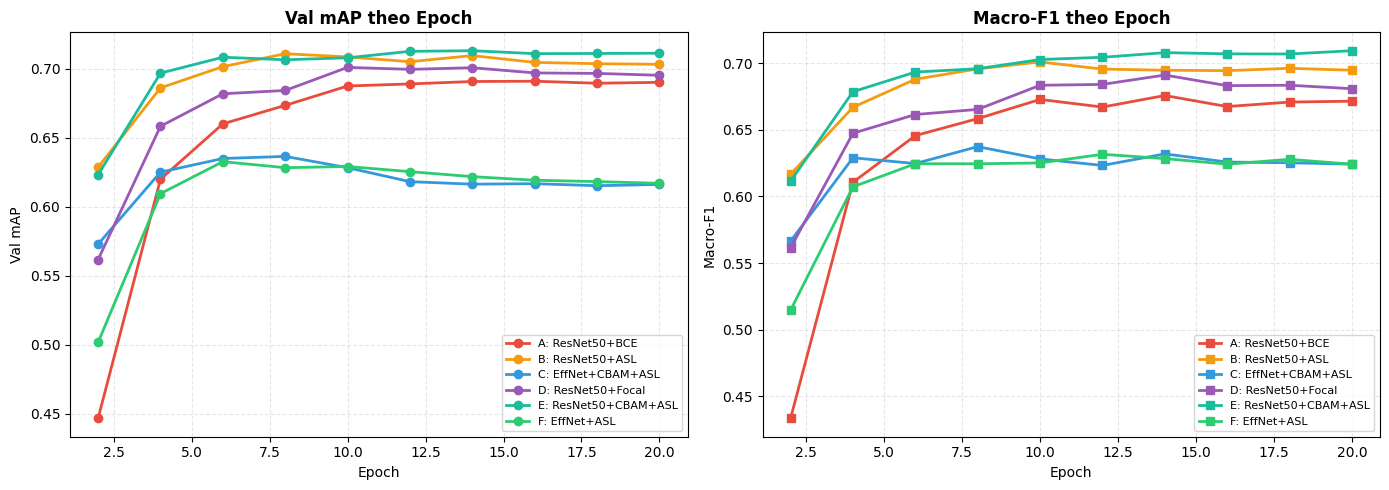


Đường cong lưu tại: /kaggle/working/outputs/ablation_curves.png


In [13]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS_DIR = Path("/kaggle/working/outputs")

EXP_ORDER = [
    ("A: ResNet50+BCE",       "exp_A_resnet_bce"),
    ("B: ResNet50+ASL",       "exp_B_resnet_asl"),
    ("C: EffNet+CBAM+ASL",    "exp_C_efficientnet_cbam_asl"),
    ("D: ResNet50+Focal",     "exp_D_resnet_focal"),
    ("E: ResNet50+CBAM+ASL",  "exp_E_resnet_cbam_asl"),
    ("F: EffNet+ASL",         "exp_F_efficientnet_asl"),
]
COLORS = ["#e74c3c", "#f39c12", "#3498db", "#9b59b6", "#1abc9c", "#2ecc71"]

# Đọc logs
rows, logs = [], {}
for name, exp_dir in EXP_ORDER:
    log_path = OUTPUTS_DIR / exp_dir / "log.json"
    if not log_path.exists():
        print(f"Log không tìm thấy: {log_path}")
        continue
    records = json.load(open(log_path))
    logs[name] = records
    best = max(records, key=lambda r: r.get("mAP", 0))
    rows.append({
        "Experiment":  name,
        "Best mAP":    f"{best['mAP']:.4f}",
        "Macro-F1":    f"{best.get('macro_f1', 0):.4f}",
        "Best Epoch":  best["epoch"],
    })

# Bảng tóm tắt
print("\n" + "=" * 65)
print("ABLATION STUDY - VAL mAP (best epoch)")
print("=" * 65)
df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
print("=" * 65)

# Phân tích đóng góp thành phần
def get_map(prefix):
    r = next((r for r in rows if r["Experiment"].startswith(prefix)), None)
    return float(r["Best mAP"]) if r else None

print()
pairs = [
    ("ASL vs BCE (ResNet)",       "A:", "B:", "+"),
    ("Focal vs BCE (ResNet)",     "A:", "D:", "+"),
    ("CBAM trên ResNet",          "B:", "E:", "+"),
    ("CBAM trên EfficientNet",    "F:", "C:", "+"),
    ("EfficientNet vs ResNet+ASL","B:", "F:", ""),
]
for label, ref, target, sign in pairs:
    r, t = get_map(ref), get_map(target)
    if r is not None and t is not None:
        delta = t - r
        print(f"  {label:<35}  {ref[:1]}={r:.4f} → {target[:1]}={t:.4f}  Δ={delta:+.4f}")

# Đường cong huấn luyện
if logs:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for (name, recs), color in zip(logs.items(), COLORS):
        ep  = [r["epoch"]     for r in recs]
        mAP = [r["mAP"]       for r in recs]
        f1  = [r.get("macro_f1", 0) for r in recs]
        ax1.plot(ep, mAP, marker="o", label=name, color=color, linewidth=2)
        ax2.plot(ep, f1,  marker="s", label=name, color=color, linewidth=2)

    for ax, title, ylabel in [
        (ax1, "Val mAP theo Epoch",    "Val mAP"),
        (ax2, "Macro-F1 theo Epoch",   "Macro-F1"),
    ]:
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8, loc="best")
        ax.grid(alpha=0.3, linestyle="--")

    plt.tight_layout()
    out_path = OUTPUTS_DIR / "ablation_curves.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nĐường cong lưu tại: {out_path}")
else:
    print("Không tìm thấy log nào. Hãy chạy các cell train trước.")
